# Predictive Maintenance intelligence system

# Data Understanding

**Author:** Anushka

### Objective
Understand the dataset, inspect its structure, identify the target variable, and assess data quality before building machine learning models.

In [2]:
# ==========================================
# Import required libraries
# ==========================================

import pandas as pd
import numpy as np

# Display all columns
pd.set_option("display.max_columns", None)

# Load the dataset
df = pd.read_csv("D:\\ml projects\\predictive-maintenance-ml\\data\\raw\\predictive_maintenance.csv")

# Display the first five rows
df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
#Understand the Dataset Structure

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type                 10000 non-null  object 
 1   Air temperature      10000 non-null  float64
 2   Process temperature  10000 non-null  float64
 3   Rotational speed     10000 non-null  int64  
 4   Torque               10000 non-null  float64
 5   Tool wear            10000 non-null  int64  
 6   Machine failure      10000 non-null  int64  
 7   TWF                  10000 non-null  int64  
 8   HDF                  10000 non-null  int64  
 9   PWF                  10000 non-null  int64  
 10  OSF                  10000 non-null  int64  
 11  RNF                  10000 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 937.6+ KB


In [4]:
df.shape

(10000, 12)

In [5]:
# Understand the numerical features

df.describe()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [6]:
df.columns

Index(['Type', 'Air temperature', 'Process temperature', 'Rotational speed',
       'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [2]:
# check the target variable

df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

### Observation

- The dataset contains **10,000 machine records**.
- **9,661 (96.61%)** records represent machines with **no failure**.
- **339 (3.39%)** records represent machines that **failed**.
- The target variable is **highly imbalanced**, which is common in predictive maintenance datasets.
- Therefore, evaluation metrics such as **Precision, Recall, F1-score, ROC-AUC, and the Confusion Matrix** will be more appropriate than accuracy alone.

In [6]:
# Check for missing values

df.isnull().sum()

Type                   0
Air temperature        0
Process temperature    0
Rotational speed       0
Torque                 0
Tool wear              0
Machine failure        0
TWF                    0
HDF                    0
PWF                    0
OSF                    0
RNF                    0
dtype: int64

In [7]:
# Check for duplicate rows

df.duplicated().sum()

np.int64(0)

In [8]:
# Check data types

df.dtypes

Type                    object
Air temperature        float64
Process temperature    float64
Rotational speed         int64
Torque                 float64
Tool wear                int64
Machine failure          int64
TWF                      int64
HDF                      int64
PWF                      int64
OSF                      int64
RNF                      int64
dtype: object

In [9]:
df.nunique()

Type                     3
Air temperature         93
Process temperature     82
Rotational speed       941
Torque                 577
Tool wear              246
Machine failure          2
TWF                      2
HDF                      2
PWF                      2
OSF                      2
RNF                      2
dtype: int64

### Observation

- The dataset contains **no duplicate rows**.
- Every machine record is unique.
- No duplicate removal is required before model training.

### Data Type Observations

- The dataset contains one categorical feature (`Type`) and several numerical features.
- `Machine failure` is the target variable for binary classification.
- The failure type columns (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`) represent specific failure causes and will be excluded during model training to avoid target leakage.
- The dataset has appropriate data types and requires minimal preprocessing.

# visualizaton

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look better
plt.style.use("ggplot")

# Default figure size
plt.rcParams["figure.figsize"] = (8,5)

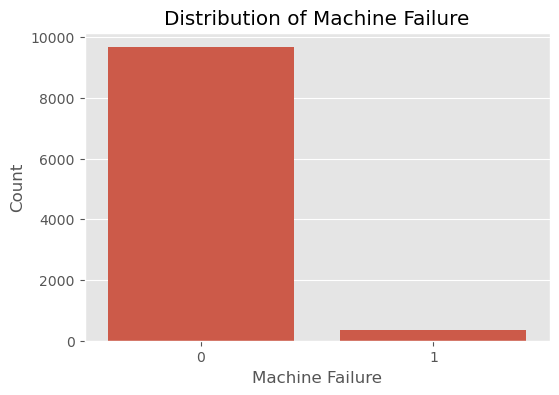

In [11]:
# To confirms the imbalance (count plot)

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Machine failure"
)

plt.title("Distribution of Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

### Observation

- Most machines belong to the **No Failure** class.
- Machine failures are relatively rare.
- The dataset is highly imbalanced.
- Accuracy alone is not an appropriate evaluation metric.
- Precision, Recall and F1-score will be important during model evaluation.

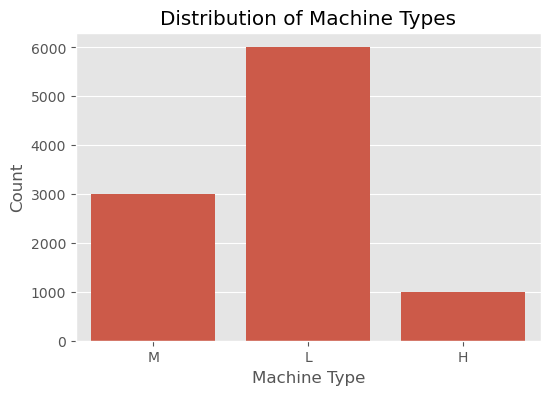

In [12]:
# Machine Type Distribution (count plot)

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Type"
)

plt.title("Distribution of Machine Types")
plt.xlabel("Machine Type")
plt.ylabel("Count")

plt.show()

In [13]:
# Check the unique machine types

df["Type"].unique()

array(['M', 'L', 'H'], dtype=object)

### Observation

- The dataset contains three machine types: L, M, and H.

### Business Insight

Understanding the distribution of machine types helps determine whether certain machine categories are overrepresented. 
This information is useful when analyzing failure patterns across different machine types.

### Observation

- The dataset contains three machine types: **L (Low), M (Medium), and H (High)**.
- **L-type machines** have the highest number of records, followed by **M-type** machines.
- **H-type machines** have the lowest representation in the dataset.
- The distribution of machine types is **imbalanced**, with L-type machines making up the majority of the dataset.
    
### Business Insight

The machine types are not equally represented in the dataset. Since L-type machines are more common, they may naturally have a higher number of
recorded failures. Therefore, during analysis, we should compare **failure rates** rather than only the total number of failures to avoid misleading
conclusions.

In [14]:
# Distribution of Numerical Features

numerical_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

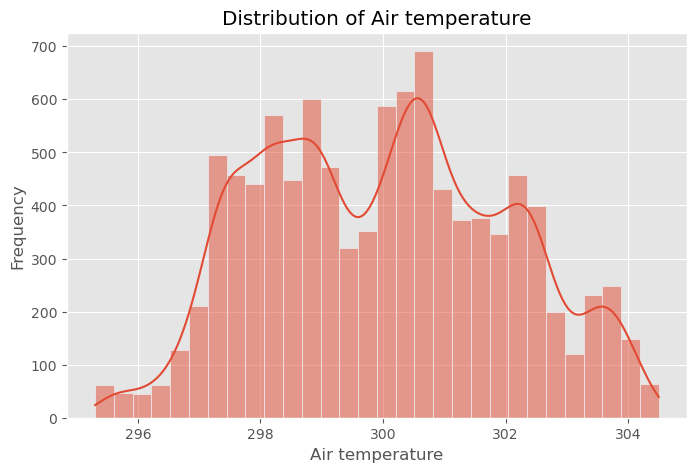

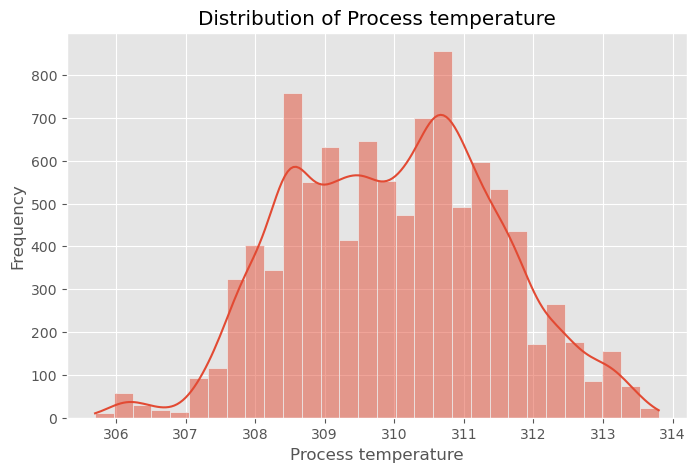

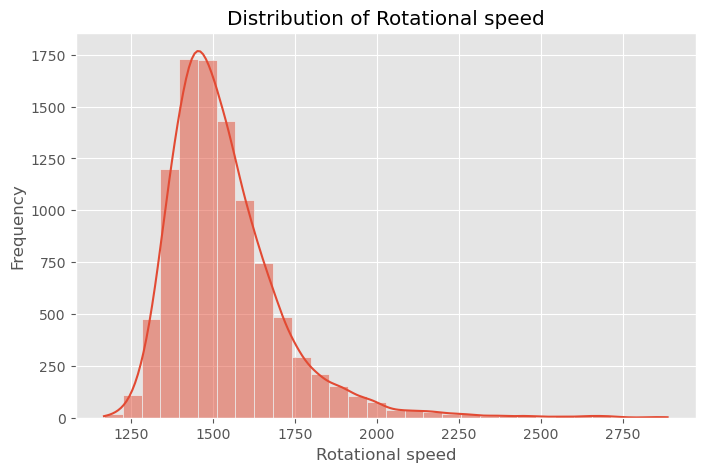

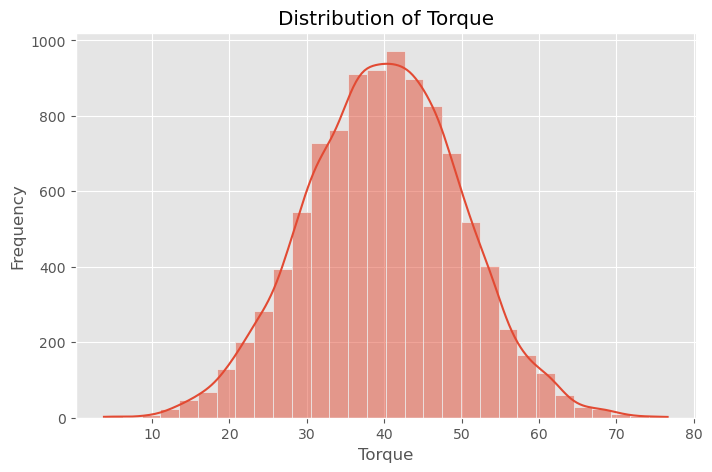

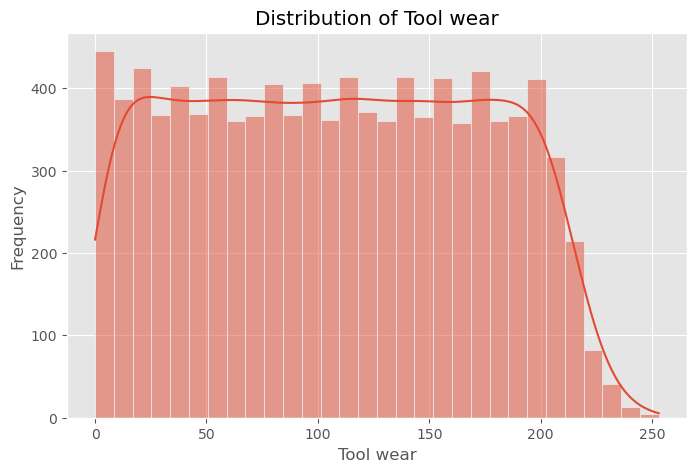

In [15]:
for feature in numerical_features:

    plt.figure(figsize=(8,5))

    sns.histplot(
        data=df,
        x=feature,
        bins=30,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

### Observation

- **Air Temperature:** Approximately normally distributed with no major abnormalities.
- **Process Temperature:** Approximately normally distributed and concentrated around 309–311 K.
- **Rotational Speed:** Positively skewed, with most machines operating between 1400–1600 RPM and a few operating at much higher speeds.
- **Torque:** Approximately normally distributed with most values between 30–50 Nm.
- **Tool Wear:** Nearly uniformly distributed up to around 200 minutes, after which the frequency decreases.

### Business Insight

The numerical features exhibit different distribution patterns. Air temperature, process temperature, and torque show relatively stable operating conditions, while rotational speed and tool wear display greater variability. Understanding these distributions helps identify potential outliers and guides preprocessing decisions before model training.

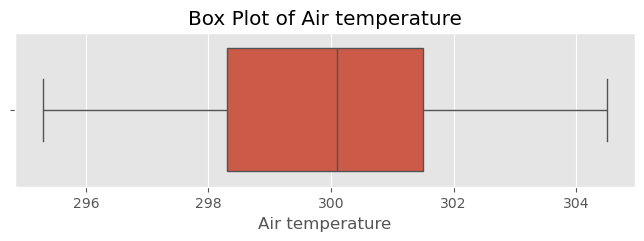

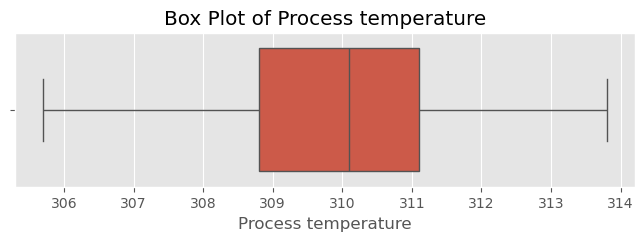

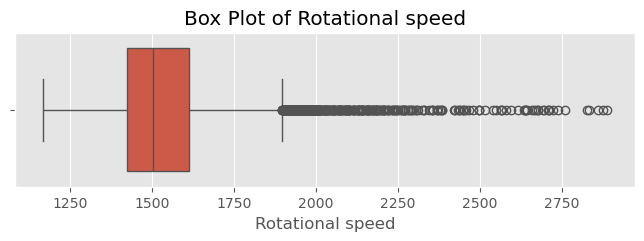

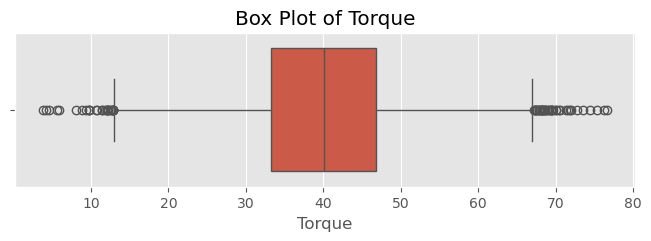

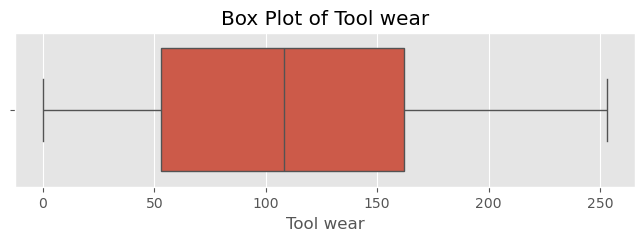

In [16]:
# Outlier Detection  (Box Plots)

numerical_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

for feature in numerical_features:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        data=df,
        x=feature
    )

    plt.title(f"Box Plot of {feature}")

    plt.show()

### Observation

- **Air Temperature:** No significant outliers were detected.
- **Process Temperature:** No significant outliers were detected.
- **Rotational Speed:** Contains several high-value outliers, indicating some machines operate at much higher speeds than the majority.
- **Torque:** Contains a few outliers at both the lower and upper ends of the distribution.
- **Tool Wear:** No significant outliers were observed.

### Business Insight

Most numerical features do not contain significant outliers. The outliers observed in rotational speed and torque are likely to represent valid operating conditions rather than data errors. In predictive maintenance, these extreme values can provide valuable information for identifying machine failures, so they should be retained for model training.

In [17]:
#Correlation Analysis (Heatmap) 

# Select Numerical Columns

numerical_df = df.select_dtypes(include=["int64", "float64"])

#Compute Correlation

correlation_matrix = numerical_df.corr()


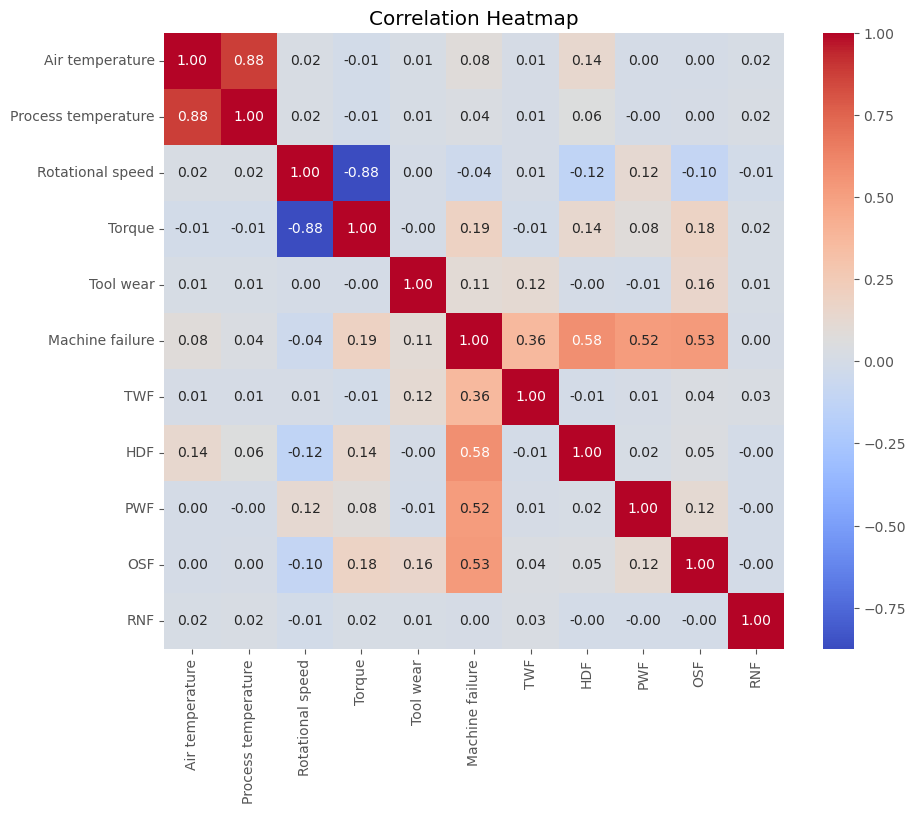

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Air temperature and process temperature show a strong positive correlation (0.88).
- Rotational speed and torque show a strong negative correlation (-0.88).
- The remaining numerical features exhibit weak correlations with each other.
- Failure type columns (TWF, HDF, PWF, OSF) have moderate correlations with the target variable, but they represent specific failure categories rather than independent input features.

### Business Insight

The heatmap reveals meaningful relationships between operating conditions, such as the inverse relationship between rotational speed and torque. It also highlights the importance of identifying target leakage. Failure type columns contain information about the occurrence of failures and should be excluded during model training to ensure a realistic predictive model.

In [19]:
# Create a New DataFrame and to drop the failure type columns

df_model = df.drop(
    columns=[
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

# To verify the columns

df_model.columns

Index(['Type', 'Air temperature', 'Process temperature', 'Rotational speed',
       'Torque', 'Tool wear', 'Machine failure'],
      dtype='object')

## Objective

Remove target leakage columns before model training.

### Observation

The failure type columns (TWF, HDF, PWF, OSF, RNF) were removed because they directly indicate the occurrence of machine failures. Retaining them would introduce target leakage and lead to unrealistic model performance.

### Business Insight

The predictive model should rely only on operational machine data available before a failure occurs. Removing leakage features ensures that the model can generalize to real-world scenarios.

In [20]:
# Separate Features (X) and Target (y)

X = df_model.drop("Machine failure", axis=1)
y = df_model["Machine failure"]

In [21]:
X.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [22]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64

In [24]:
# To check shapes

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 6)
y shape: (10000,)


## Objective

Separate the dataset into input features (X) and target variable (y).

### Observation

The feature set (X) contains six input variables used to predict machine failure. The target variable (y) contains the binary machine failure labels.

### Business Insight

Separating features from the target ensures that the machine learning model learns patterns from operational machine data without accessing the outcome during training.

In [25]:
# Encode the Categorical Feature (Type)

X = pd.get_dummies(
    X,
    columns=["Type"],
    drop_first=True,
    dtype=int
)
    

In [26]:
# Verify the Encoding

X.head()

,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,1
1,298.2,308.7,1408,46.3,3,1,0
2,298.1,308.5,1498,49.4,5,1,0
3,298.2,308.6,1433,39.5,7,1,0
4,298.2,308.7,1408,40.0,9,1,0


In [27]:
# Check the Columns

X.columns

Index(['Air temperature', 'Process temperature', 'Rotational speed', 'Torque',
       'Tool wear', 'Type_L', 'Type_M'],
      dtype='object')

## Objective

Convert the categorical machine type feature into numerical variables using One-Hot Encoding.

### Observation

The categorical `Type` column was transformed into binary indicator variables (`Type_L` and `Type_M`). The `Type_H` category is represented implicitly because `drop_first=True` was used.

### Business Insight

Machine learning algorithms require numerical input. One-Hot Encoding preserves the categorical nature of machine types without introducing an artificial order, helping the model learn differences between machine categories more effectively.

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
# Split the Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
# Verify the Shapes

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 7)
X_test : (2000, 7)
y_train: (8000,)
y_test : (2000,)


In [31]:
# Verify Class Distribution

print(y_train.value_counts(normalize=True))

print()

print(y_test.value_counts(normalize=True))

Machine failure
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Machine failure
0    0.966
1    0.034
Name: proportion, dtype: float64


## Objective

Split the dataset into training and testing sets for model development and evaluation.

### Observation

The dataset was split into 80% training data and 20% testing data. Stratified sampling was used to preserve the original class distribution in both subsets.

### Business Insight

Evaluating the model on unseen data provides a realistic estimate of its performance in production. Stratified sampling ensures that the rare machine failure cases are represented in both the training and testing datasets.

In [32]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

In [33]:
# Create the Scaler

scaler = StandardScaler()

In [34]:
# Fit on Training Data

X_train_scaled = scaler.fit_transform(X_train)

In [35]:
# Scale Test Data

X_test_scaled = scaler.transform(X_test)

In [36]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(8000, 7)
(2000, 7)


In [37]:
# Look at the Scaled Data

X_train_scaled[:5]

array([[ 0.99891359,  0.60428162, -0.46060741,  0.71830476, -0.84399726,
        -1.23436595,  1.53620728],
       [-1.50519408, -1.15325984, -0.77557391,  0.63845583,  0.38226308,
        -1.23436595,  1.53620728],
       [ 0.49809206,  1.07746586, -1.00765448,  0.5586069 ,  0.46086951,
        -1.23436595,  1.53620728],
       [-0.55363316, -0.13929361, -0.70926517,  1.62658635, -0.37235867,
         0.81013252, -0.65095382],
       [-1.45511192, -1.01806434,  1.07001923, -1.12820177, -0.90688241,
         0.81013252, -0.65095382]])

## Objective

Scale numerical features using StandardScaler.

### Observation

The scaler was fitted using only the training dataset and then applied to both the training and testing datasets. This prevents data leakage while ensuring that all features have comparable scales.

### Business Insight

Feature scaling improves the performance of distance-based and gradient-based machine learning algorithms by preventing variables with larger numerical ranges from dominating the learning process.

### Logistic Regression ###

In [38]:
# Import the Algorithm

from sklearn.linear_model import LogisticRegression

In [39]:
# Create the Model

model_lr = LogisticRegression(random_state=42)

In [40]:
# Train the Model

model_lr.fit(X_train_scaled, y_train)     

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [41]:
# Testing the model or Make Predictions

y_pred_lr = model_lr.predict(X_test_scaled)

In [42]:
# Import Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [43]:
# Calculate Accuracy

accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", accuracy)

Accuracy: 0.9675


In [44]:
# Print the Confusion Matrix

cm = confusion_matrix(y_test, y_pred_lr)

print(cm)

[[1928    4]
 [  61    7]]


In [45]:
# Print the Classification Report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.64      0.10      0.18        68

    accuracy                           0.97      2000
   macro avg       0.80      0.55      0.58      2000
weighted avg       0.96      0.97      0.96      2000



## Objective

Evaluate the Logistic Regression model using standard classification metrics.

### Observation

The model's predictions were compared with the actual test labels to calculate performance metrics such as accuracy, confusion matrix, precision, recall, and F1-score.

### Business Insight

Evaluating the model helps determine how reliably it can identify machine failures. In predictive maintenance, reducing missed failures is often more important than achieving high overall accuracy.

### Observation

- The Logistic Regression model achieved an overall accuracy of **96.75%**.
- It correctly identified **1928** healthy machines and **7** machine failures.
- The model missed **61** actual failures, resulting in a low recall (**10%**) for the failure class.
- This indicates that the dataset is imbalanced and the model favors the majority class.

### Business Insight

Although the model has high overall accuracy, it fails to detect many machine failures. In predictive maintenance, missing a failure can lead to unexpected breakdowns and increased maintenance costs. Therefore, improving recall for the failure class is more important than maximizing overall accuracy.

### Decision Tree ###

In [46]:
# Import Decision Tree

from sklearn.tree import DecisionTreeClassifier

In [47]:
# Create the Model

model_dt = DecisionTreeClassifier(random_state=42)

In [48]:
# Train the Model

model_dt.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [49]:
# Make Predictions

y_pred_dt = model_dt.predict(X_test_scaled)

In [50]:
# Evaluate the Model

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print()

print(confusion_matrix(y_test, y_pred_dt))
print()

print(classification_report(y_test, y_pred_dt))

Accuracy: 0.978

[[1911   21]
 [  23   45]]

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.68      0.66      0.67        68

    accuracy                           0.98      2000
   macro avg       0.83      0.83      0.83      2000
weighted avg       0.98      0.98      0.98      2000



### Observation

- The Decision Tree model achieved an accuracy of **97.8%**.
- It correctly identified **1911** healthy machines and **45** machine failures.
- The model missed **23** actual failures, which is significantly fewer than Logistic Regression.
- The Decision Tree achieved much higher recall and F1-score for the machine failure class.

### Business Insight

Compared with Logistic Regression, the Decision Tree is more effective at detecting machine failures. Although it generates more false alarms, it significantly reduces missed failures, making it a better choice for predictive maintenance where preventing unexpected machine breakdowns is critical.

### Random Forest Classifier ###


In [51]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

In [52]:
# Create the Model

model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [53]:
# Train the Model

model_rf.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
# Make Predictions

y_pred_rf = model_rf.predict(X_test_scaled)

In [55]:
# Evaluate the Model

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print()

print(confusion_matrix(y_test, y_pred_rf))
print()

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9815

[[1927    5]
 [  32   36]]

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.53      0.66        68

    accuracy                           0.98      2000
   macro avg       0.93      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000



### Observation

- The Random Forest model achieved an accuracy of **98.15%**, the highest among all tested models.
- It correctly identified **1927** healthy machines and **36** machine failures.
- The model produced only **5 false positives**, resulting in a high precision of **0.88**.
- However, it missed **32** machine failures, giving a recall of **0.53**, which is lower than the Decision Tree model.

### Business Insight

Random Forest provides excellent overall accuracy and minimizes false alarms, making its failure predictions highly reliable. However, because predictive maintenance prioritizes detecting as many actual failures as possible, the Decision Tree model may be a better choice due to its higher recall and lower number of missed failures.

### Hyperparameter Tuning ###

In [56]:
# Import GridSearchCV

from sklearn.model_selection import GridSearchCV

In [57]:
# Create the Parameter Grid

param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

In [58]:
# Create GridSearchCV

grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)


In [59]:
# Train Grid Search

grid_dt.fit(X_train_scaled, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [60]:
# View the Best Parameters

print("Best Parameters:", grid_dt.best_params_)
print("Best Recall Score:", grid_dt.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Best Recall Score: 0.7084848484848484


In [61]:
# Make prediction 

y_pred_best_dt = grid_dt.predict(X_test_scaled)

In [62]:
# Evaluate the Tuned Model

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_best_dt))
print()

print(confusion_matrix(y_test, y_pred_best_dt))
print()

print(classification_report(y_test, y_pred_best_dt))

Accuracy: 0.975

[[1908   24]
 [  26   42]]

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1932
           1       0.64      0.62      0.63        68

    accuracy                           0.97      2000
   macro avg       0.81      0.80      0.81      2000
weighted avg       0.97      0.97      0.97      2000



## Comparison of Original and Tuned Decision Tree

### Observation

- Hyperparameter tuning was performed using GridSearchCV with recall as the optimization metric.
- The tuned Decision Tree achieved 97.5% accuracy, while the original Decision Tree achieved 97.8%.
- The original model also had higher recall (0.66 vs 0.62) and detected more machine failures (45 vs 42).

### Business Insight

Although hyperparameter tuning explored multiple parameter combinations, the original Decision Tree performed better on the unseen test data. Therefore, the original Decision Tree was selected as the final model because it detected more machine failures, which is the primary objective of predictive maintenance.

### Feature Importance ###

In [63]:
# Get Feature Importance 

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model_dt.feature_importances_
})

In [64]:
# Sort the Features

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,Torque,0.365386
0,Air temperature,0.202223
4,Tool wear,0.148901
1,Process temperature,0.132705
2,Rotational speed,0.126795
5,Type_L,0.015196
6,Type_M,0.008795


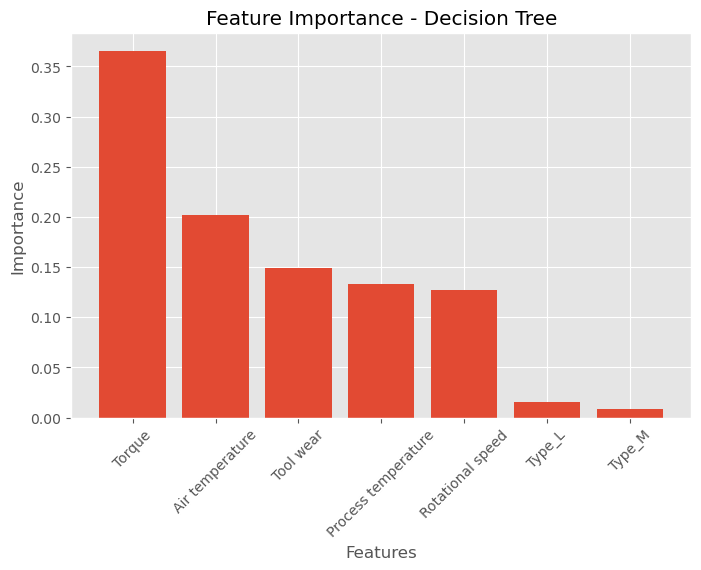

In [65]:
# Visualize

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)

plt.show()

## Feature Importance

### Objective

Identify the most influential features used by the Decision Tree model to predict machine failures.

### Observation

- Torque was the most important feature used by the model.
- Air temperature and Tool wear also contributed significantly to the predictions.
- Process temperature and Rotational speed had moderate importance.
- Machine type (Type_L and Type_M) had minimal influence on the prediction.

### Business Insight

The model indicates that machine operating conditions, particularly Torque, Air Temperature and Tool Wear, play the biggest role in predicting failures. Maintenance teams should closely monitor these parameters to detect abnormal operating conditions early and reduce unexpected equipment breakdowns.

### Save the Best Model ###

In [71]:
# Import Joblib

import joblib

In [81]:
# Save the Decision Tree

joblib.dump(model_dt, "../models/decision_tree_model.pkl")

['../models/decision_tree_model.pkl']

In [83]:
# Load the Model

loaded_model = joblib.load("../models/decision_tree_model.pkl")

In [85]:
import joblib

# Save the scaler
joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!


## Model Saving

### Objective

Save the trained Decision Tree model for future use without retraining.

### Observation

The final Decision Tree model was successfully saved as a `.pkl` file using Joblib.

### Business Insight

Saving the trained model allows it to be reused for future predictions and deployment without retraining, improving efficiency in production environments.

### Create Sample Data ###

In [86]:
print(X.columns)

Index(['Air temperature', 'Process temperature', 'Rotational speed', 'Torque',
       'Tool wear', 'Type_L', 'Type_M'],
      dtype='object')


In [87]:
# Create a Prediction Function

def predict_machine(
    air_temperature,
    process_temperature,
    rotational_speed,
    torque,
    tool_wear,
    machine_type
):
    # One-Hot Encoding
    type_l = 1 if machine_type.upper() == "L" else 0
    type_m = 1 if machine_type.upper() == "M" else 0

    # Create DataFrame
    new_machine = pd.DataFrame({
        "Air temperature": [air_temperature],
        "Process temperature": [process_temperature],
        "Rotational speed": [rotational_speed],
        "Torque": [torque],
        "Tool wear": [tool_wear],
        "Type_L": [type_l],
        "Type_M": [type_m]
    })

    # Scale the Data
    new_machine_scaled = scaler.transform(new_machine)

    # Predict
    prediction = loaded_model.predict(new_machine_scaled)[0]

    # Prediction Probabilities
    probability = loaded_model.predict_proba(new_machine_scaled)[0]

    healthy_probability = probability[0] * 100
    failure_probability = probability[1] * 100

    # Display Results
    if prediction == 0:
        print("✅ Machine is Healthy")
    else:
        print("⚠️ Machine Failure Predicted")

    print(f"Healthy Probability : {healthy_probability:.2f}%")
    print(f"Failure Probability : {failure_probability:.2f}%")

In [88]:
# Use the Function

predict_machine(
    air_temperature=300.5,
    process_temperature=310.8,
    rotational_speed=1450,
    torque=45.2,
    tool_wear=120,
    machine_type="M"
)

✅ Machine is Healthy
Healthy Probability : 100.00%
Failure Probability : 0.00%


## Prediction System

### Objective

Predict whether a new machine is healthy or likely to fail using the trained machine learning model and display the prediction confidence.

### Observation
The model successfully predicts the machine condition.
The prediction probabilities indicate how confident the model is in its decision.
Both the healthy and failure probabilities are displayed for better interpretability.

### Business Insight
Displaying prediction probabilities helps maintenance engineers understand the certainty of the model's predictions. Machines with higher failure probabilities can be prioritized for inspection, reducing unexpected downtime and improving maintenance planning.

## Model Comparison

In [89]:
# Model Comparison

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": model_lr,
    "Decision Tree": model_dt,
    "Random Forest": model_rf
}

results = []

for name, model in models.items():

    predictions = model.predict(X_test_scaled)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9675,0.636364,0.102941,0.177215
1,Decision Tree,0.9780,0.681818,0.661765,0.671642
2,Random Forest,0.9815,0.878049,0.529412,0.660550


In [90]:
#  sort by Recall

comparison.sort_values(
    by="Recall",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.9780,0.681818,0.661765,0.671642
2,Random Forest,0.9815,0.878049,0.529412,0.660550
0,Logistic Regression,0.9675,0.636364,0.102941,0.177215


In [91]:
# Formatting

comparison.style.format({
    "Accuracy": "{:.4f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1 Score": "{:.4f}"
})

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9675,0.6364,0.1029,0.1772
1,Decision Tree,0.9780,0.6818,0.6618,0.6716
2,Random Forest,0.9815,0.8780,0.5294,0.6606


## Objective

Compare the performance of all trained machine learning models using standard evaluation metrics to identify the most suitable model for predictive maintenance.

### Observation

- Logistic Regression produced the lowest recall and missed many machine failures.
- Random Forest achieved the highest accuracy and precision.
- Decision Tree achieved the highest recall and F1-score, making it the most effective model for identifying machine failures.

### Business Insight

In predictive maintenance, identifying actual machine failures is more important than maximizing overall accuracy. Since the Decision Tree achieved the highest recall, it is the preferred model because it reduces the chance of missing machines that are likely to fail.